# ANÁLISE DE DADOS ELEITORAIS ESPACIALIZADOS NO ESTADO DO RIO DE JANEIRO EM 2022
Apresenta a análise dos dados com uma exibição base em python.

### IMPORTS DE BIBLIOTECAS NECESSÁRIAS

In [1]:
# Import de bibliotecas

!pip install esda libpysal splot

try:
  import matplotlib
  print('Matplotlib is already installed!')
  print(f'Matplotlib version: {matplotlib.__version__}\n')
except ImportError:
  print('Installing Matplotlib...')
  !pip install matplotlib

try:
  import numpy
  print('Numpy is already installed!')
  print(f'Numpy version: {numpy.__version__}\n')
except ImportError:
  print('Installing Numpy...')
  !pip install numpy

try:
  import pandas
  print('Pandas is already installed!')
  print(f'Pandas version: {pandas.__version__}\n')
except ImportError:
  print('Installing Pandas...')
  !pip install pandas

try:
    import geopandas as gpd
    print('GeoPandas is already installed!')
    print(f'GeoPandas version: {gpd.__version__}\n')
except ImportError:
    print('Installing GeoPandas...')
    !pip install geopandas
    import geopandas as gpd
    print(f'GeoPandas version: {gpd.__version__}\n')

try:
  import pyarrow as pa
  print('PyArrow is already installed!')
  print(f'PyArrow version: {pa.__version__}\n')
except ImportError:
  print('Installing PyArrow...')
  !pip install pyarrow

try:
  import os
  print('OS is already installed!')
except ImportError:
  print('Installing OS...')
  !pip install os



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\Dell\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Matplotlib is already installed!
Matplotlib version: 3.10.3

Numpy is already installed!
Numpy version: 2.2.5

Pandas is already installed!
Pandas version: 2.2.3

GeoPandas is already installed!
GeoPandas version: 1.0.1

PyArrow is already installed!
PyArrow version: 20.0.0

OS is already installed!


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import seaborn as sns
from libpysal.weights import Queen
from esda.moran import Moran_BV
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import requests

import geopandas as gpd

C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### DEFINIÇÃO DOS CAMINHOS DOS ARQUIVOS ORIGINAIS E VISUALIZAÇÃO INICIAL DOS MESMOS

In [3]:
# Caminho dos dados

path_alfabetizacao_csv = "./DADOS/Alfabetizacao/Agregados_por_municipios_alfabetizacao_BR.csv"
path_seguranca_csv = "./DADOS/Seguranca/BaseMunicipioMensal.csv"
# path_votos_TSE_csv = "./DADOS/TSE/votacao_candidato_munzona_2022_RJ.csv"
path_malha_zip = "./DADOS/MalhaGeometrica/rj_municipios.zip"
path_votos_TSE_csv = "./DADOS/TSE/votos_filtrados.csv"


# Leitura dos arquivos para dataframes -> usando pandas

# Lê o arquivo CSV e carrega em um DataFrame
df_alfabetizacao = pd.read_csv(path_alfabetizacao_csv,  encoding='latin1', sep=';')
df_seguranca = pd.read_csv(path_seguranca_csv,  encoding='latin1', sep=';')

# df_votos = pd.read_csv(path_votos_TSE_csv, encoding='latin1', sep='')
df_votos = pd.read_csv(path_votos_TSE_csv, encoding='latin1', sep=';')

In [4]:
# Verificação das primeiras linhas dos dados

# Exibe as primeiras 5 linhas do DataFrame
print("Data frame de alfabetização: \n")
print(df_alfabetizacao.head())

print("Data frame de segurança: \n")
print(df_seguranca.head())
# print(df_votos.head())

Data frame de alfabetização: 

    CD_MUN                 NM_MUN  V00644  V00645  V00646  V00647  V00648  \
0  1100015  Alta Floresta D'Oeste    1644    1514    1557    1643    1511   
1  1100023              Ariquemes    7666    8193    8053    7656    7741   
2  1100031                 Cabixi     373     246     306     373     402   
3  1100049                 Cacoal    6299    7292    7282    7029    6858   
4  1100056             Cerejeiras    1142    1044    1275    1285    1222   

   V00649  V00650  V00651  ...  V00996  V00997  V00998  V00999  V01000  \
0    1576    1541    1352  ...     109     226     119      40      73   
1    7404    6582    5774  ...     484    1106     506     328     591   
2     425     338     399  ...       3      29      21       3       9   
3    6765    5774    5377  ...     489    1181     401     279     430   
4    1142    1083     967  ...     101     172      84      36      90   

   V01001  V01002  V01003  V01004  V01005  
0      51     107

In [5]:
df_raw = pd.read_csv(path_votos_TSE_csv, header=None, encoding='latin-1')

df_votos = df_raw[0].str.replace('"', '').str.split(';', expand=True)

df_votos.columns = df_votos.iloc[0]
df_votos = df_votos[1:] 

df_votos = df_votos.reset_index(drop=True)

# print(df_votos.head())
# print(df_votos.columns[:10])
# print(df_votos.shape)

### VERIFICAÇÃO DA MALHA GEOGRÁFICA

In [6]:
rj = gpd.read_file('./DADOS/MalhaGeometrica/rj_municipios/33MUE250GC_SIR.shp')
rj.head()


,ID,CD_GEOCODM,NM_MUNICIP,geometry
0,1468,3300100,ANGRA DOS REIS,"MULTIPOLYGON (((-44.33208 -23.02384, -44.33221..."
1,1469,3300159,APERIBÉ,"POLYGON ((-42.0895 -21.62893, -42.08912 -21.62..."
2,1470,3300209,ARARUAMA,"POLYGON ((-42.22526 -22.59253, -42.22521 -22.5..."
3,1471,3300225,AREAL,"POLYGON ((-43.16007 -22.20005, -43.16003 -22.1..."
4,1472,3300233,ARMAÇÃO DOS BÚZIOS,"MULTIPOLYGON (((-41.98427 -22.74458, -41.98296..."


<Axes: >

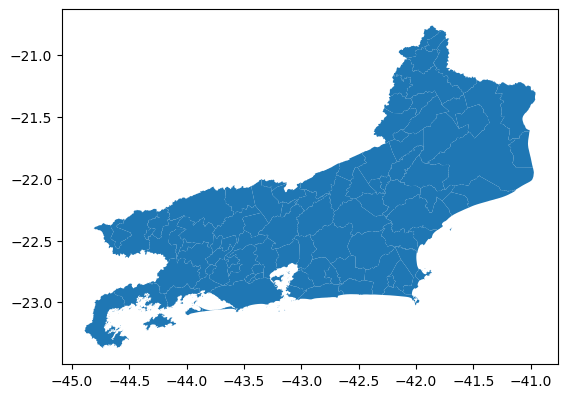

In [7]:
rj.plot()

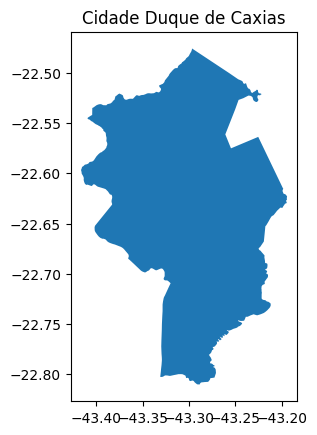

In [8]:
duque_de_caxias_city = rj[rj.NM_MUNICIP == 'DUQUE DE CAXIAS'].reset_index(drop=True)
ax2 = duque_de_caxias_city.plot()
ax2.set_title('Cidade Duque de Caxias');

### GERAÇÃO DOS CSVs FILTRADOS

In [9]:
# Filtro das colunas necessárias de alfabetização

path_alfabetizacao_csv_filtrado = "./DADOS/Alfabetizacao/por_municipio_filtrado_categorias_totais.csv"

if not os.path.exists(path_alfabetizacao_csv_filtrado):
    # Le CSV novamente por garantia
    df_alfabetizacao = pd.read_csv(path_alfabetizacao_csv, sep=';', encoding='latin1')

    df_alfabetizacao.columns = df_alfabetizacao.columns.str.strip()
    print("Colunas do CSV:", df_alfabetizacao.columns.tolist())

    colunas_base = ["CD_MUN", "NM_MUN"]
    colunas_base_existentes = [c for c in colunas_base if c in df_alfabetizacao.columns]

    if len(colunas_base_existentes) < len(colunas_base):
        raise ValueError(f"Algumas colunas base não existem no CSV: {colunas_base}.\nColunas existentes: {df_alfabetizacao.columns.tolist()}")

    # Filtrar apenas as colunas V00748 a V00760 presentes no CSV
    colunas_alfabetizacao = []
    for i in range(48, 61):  # de 48 até 60
        col = f"V007{i}"
        if col in df_alfabetizacao.columns:
            colunas_alfabetizacao.append(col)


    colunas_desejadas = colunas_base_existentes + colunas_alfabetizacao

    df_filtrado = df_alfabetizacao[colunas_desejadas]

    # Salvar CSV filtrado pronto
    df_filtrado.to_csv(path_alfabetizacao_csv_filtrado, sep=';', index=False, quoting=1, encoding='latin1')

    print(f"✅ CSV filtrado criado com sucesso: {path_alfabetizacao_csv_filtrado}")
else:
    print(f"📌 Arquivo já existe: {path_alfabetizacao_csv_filtrado}")

# Filtro das linhas necessárias de alfabetização - SOMENTE RJ
path_tse = "./DADOS/TSE/municipios_brasileiros_tse.csv"
path_final = "./DADOS/Alfabetizacao/por_municipio_RJ.csv"
if not os.path.exists(path_final):

    df_alf = pd.read_csv(path_alfabetizacao_csv_filtrado, sep=';', encoding='latin1')
    df_tse = pd.read_csv(path_tse, sep=',', encoding='latin1')

    # Normalização
    df_alf.columns = df_alf.columns.str.strip()
    df_tse.columns = df_tse.columns.str.strip()

    # Converter COD_IBGE para string e padronizar com zeros à esquerda
    df_alf["CD_MUN"] = df_alf["CD_MUN"].astype(str).str.zfill(7)
    df_tse["codigo_ibge"] = df_tse["codigo_ibge"].astype(str).str.zfill(7)

    # Filtrar apenas municípios do RJ usando merge
    df_merged = df_alf.merge(df_tse[["uf", "codigo_ibge"]],
                              left_on="CD_MUN", right_on="codigo_ibge",
                              how="inner")

    df_rj = df_merged[df_merged["uf"] == "RJ"]

    colunas_base = ["CD_MUN", "NM_MUN"]
    colunas_alfabetizacao = []
    for i in range(48, 61):
        col = f"V007{i}"
        if col in df_alfabetizacao.columns:
            colunas_alfabetizacao.append(col)
    colunas_desejadas = colunas_base + colunas_alfabetizacao

    df_rj_final = df_rj[colunas_desejadas]

    df_rj_final.to_csv(path_final, sep=';', index=False, quoting=1, encoding='latin1')

    print(f"✅ Arquivo filtrado do RJ criado com sucesso: {path_final}")
else:
    print(f"📌 Arquivo já existe: {path_final}")



📌 Arquivo já existe: ./DADOS/Alfabetizacao/por_municipio_filtrado_categorias_totais.csv
📌 Arquivo já existe: ./DADOS/Alfabetizacao/por_municipio_RJ.csv


In [10]:
# Filtro dos dados de segurança - por colunas
path_seg_ano = "./DADOS/Seguranca/seguranca_municipios_ano.csv"

if not os.path.exists(path_seg_ano):
    path_seg = "./DADOS/Seguranca/BaseMunicipioMensal.csv"
    df_seg = pd.read_csv(path_seg, sep=';', encoding='latin1', engine='python')

    df_seg.columns = df_seg.columns.str.strip()

    colunas_base = ["fmun_cod", "fmun", "ano"]
    colunas_totais = ["total_roubos", "total_furtos", "registro_ocorrencias"]

    # Verificar se todas as colunas existem
    for col in colunas_base + colunas_totais:
        if col not in df_seg.columns:
            raise KeyError(f"Coluna '{col}' não encontrada. Colunas disponíveis: {df_seg.columns.tolist()}")

    df_seg = df_seg[colunas_base + colunas_totais]

    # Agrupar por município e ano, somando os valores
    df_agrupado = df_seg.groupby(["fmun_cod", "fmun", "ano"], as_index=False).sum()

    df_agrupado.to_csv(path_seg_ano, sep=';', index=False, quoting=1, encoding='latin1')
    print(f"✅ CSV de segurança anual criado: {path_seg_ano}")

else:
    print(f"📌 Arquivo já existe, não será recriado: {path_seg_ano}")


# Filtro dos dados de segurança - por linhas, mantendo apenas o ano de 2021 como interesse
path_seg_2021 = "./DADOS/Seguranca/seguranca_municipios_2021.csv"

if not os.path.exists(path_seg_2021):
    df_ano = pd.read_csv(path_seg_ano, sep=';', encoding='latin1', engine='python')

    # ---- Filtrar apenas o ano de 2021 ----
    df_2021 = df_ano[df_ano["ano"] == 2021].copy()

    # ---- Salvar CSV filtrado ----
    df_2021.to_csv(path_seg_2021, sep=';', index=False, quoting=1, encoding='latin1')
    print(f"✅ CSV de segurança apenas 2021 criado: {path_seg_2021}")

else:
    print(f"📌 Arquivo já existe, não será recriado: {path_seg_2021}")

📌 Arquivo já existe, não será recriado: ./DADOS/Seguranca/seguranca_municipios_ano.csv
📌 Arquivo já existe, não será recriado: ./DADOS/Seguranca/seguranca_municipios_2021.csv


In [11]:
# Arquivo de origem, disponivel em https://dadosabertos.tse.jus.br/dataset/resultados-2022/resource/40fdcf49-256a-4c81-87cf-711545bd1528
path_votos_TSE_csv = "./DADOS/TSE/votacao_candidato_munzona_2022_RJ.csv" 
if not os.path.exists(path_votos_TSE_csv):
    print(f"Arquivo original não encontrado. Por favor adicione-o no caminho './DADOS/TSE/votacao_candidato_munzona_2022_RJ.csv'")
else: 

    # Filtro por linhas, mantendo apenas os dados de candidatos a deputado estadual no RJ
    path_votos_deputado_estadual = "./DADOS/TSE/votos_deputado_estadual_RJ_2022.csv"
    if not os.path.exists(path_votos_deputado_estadual):
        df_urnas = pd.read_csv(path_votos_TSE_csv, sep=';', encoding='latin1', engine='python')

        # Filtrar apenas candidatos a deputado estadual (CD_CARGO = 7)
        df_deputado_estadual = df_urnas[df_urnas['CD_CARGO'] == 7].copy()

        # Salvar CSV filtrado
        df_deputado_estadual.to_csv(path_votos_deputado_estadual, sep=';', index=False, quoting=1, encoding='latin1')

        print(f"✅ CSV de votos para deputado estadual criado: {path_votos_deputado_estadual}")
    else:
        print(f"📌 Arquivo já existe, não será recriado: {path_votos_deputado_estadual}")
        
    # MANTENDO AS COLUNAS RELEVANTES DOS DADOS DE VOTOS
    path_votos_filtrados = "./DADOS/TSE/votos_filtrados.csv" # Arquivo de destino
    if not os.path.exists(path_votos_filtrados):
        df_urnas = pd.read_csv(path_votos_deputado_estadual, sep=';', encoding='latin1', engine='python')

        df_urnas.columns = df_urnas.columns.str.strip()

        colunas_votos = [
            'CD_ELEICAO', 'DS_ELEICAO',
            'CD_MUNICIPIO', 'NM_MUNICIPIO',
            'NR_CANDIDATO', 'NM_CANDIDATO', 'NR_PARTIDO', 'SG_PARTIDO', 'NM_PARTIDO',
            'NM_TIPO_DESTINACAO_VOTOS','QT_VOTOS_NOMINAIS_VALIDOS', 'DS_SIT_TOT_TURNO', 'QT_VOTOS_NOMINAIS'
        ]   

        # Verificar se todas as colunas existem
        for col in colunas_votos:
            if col not in df_urnas.columns:
                raise KeyError(f"Coluna '{col}' não encontrada. Colunas disponíveis: {df_urnas.columns.tolist()}")

        df_urnas = df_urnas[colunas_votos].copy() # Adicionado .copy() por segurança

        # Salvar no caminho de destino (path_votos_filtrados)
        df_urnas.to_csv(path_votos_filtrados, sep=';', index=False, quoting=1, encoding='latin1')
        
        # Imprimir o caminho de destino (path_votos_filtrados)
        print(f"✅ CSV de votos filtrados criado: {path_votos_filtrados}")

    else:
        print(f"📌 Arquivo já existe, não será recriado: {path_votos_filtrados}")


📌 Arquivo já existe, não será recriado: ./DADOS/TSE/votos_deputado_estadual_RJ_2022.csv
📌 Arquivo já existe, não será recriado: ./DADOS/TSE/votos_filtrados.csv


### ANÁLISE EXPLORATÓRIA


#### VERIFICAÇÃO DE DADOS INVÁLIDOS

In [12]:
# Quantidade de municipios em cada dataframe (usando .unique)
print("Quantidade de municípios DF_Alfabetização:", df_alfabetizacao['CD_MUN'].nunique())
print("Quantidade de municípios DF_Segurança:", df_seguranca['fmun_cod'].nunique())
print("Quantidade de municípios Malha Geométrica RJ:", rj['CD_GEOCODM'].nunique())
print("Quantidade de municípios DF_Votos_TSE:", df_votos['CD_MUNICIPIO'].nunique())

Quantidade de municípios DF_Alfabetização: 5570
Quantidade de municípios DF_Segurança: 92
Quantidade de municípios Malha Geométrica RJ: 92
Quantidade de municípios DF_Votos_TSE: 92


In [13]:
# Células em branco
print("Quantidade de células em branco DF_Alfabetização:", df_alfabetizacao.isnull().sum().sum())
print("Quantidade de células em branco DF_Segurança:", df_seguranca.isnull().sum().sum())
print("Quantidade de células em branco Malha Geométrica RJ:", rj.isnull().sum().sum())
print("Quantidade de células em branco DF_Votos_TSE:", df_votos.isnull().sum().sum())


Quantidade de células em branco DF_Alfabetização: 0
Quantidade de células em branco DF_Segurança: 0
Quantidade de células em branco Malha Geométrica RJ: 0
Quantidade de células em branco DF_Votos_TSE: 0


In [14]:
# Dados duplicados
print("Quantidade de dados duplicados DF_Alfabetização:", df_alfabetizacao.duplicated().sum())
print("Quantidade de dados duplicados DF_Segurança:", df_seguranca.duplicated().sum())
print("Quantidade de dados duplicados Malha Geométrica RJ:", rj.duplicated().sum())
print("Quantidade de dados duplicados DF_Votos_TSE:", df_votos.duplicated().sum())

Quantidade de dados duplicados DF_Alfabetização: 0
Quantidade de dados duplicados DF_Segurança: 0
Quantidade de dados duplicados Malha Geométrica RJ: 0
Quantidade de dados duplicados DF_Votos_TSE: 82241


#### VERIFICAÇÕES ESTATÍSTICAS
- Médias
- Municípios com mais ou menos ocorrências
- Correlações iniciais


In [15]:
# Análise estatística de furtos no estado (arquivo segurança_municipios)

df_seg = pd.read_csv("./DADOS/Seguranca/seguranca_municipios_2021.csv", sep=';', encoding='latin1')

media_furtos = df_seg["total_furtos"].mean()
media_roubos = df_seg["total_roubos"].mean()

print(f"Média de furtos por município (2021): {media_furtos:.2f}")
print(f"Média de roubos por município (2021): {media_roubos:.2f}")

max_furtos = df_seg.loc[df_seg["total_furtos"].idxmax(), ["fmun", "total_furtos"]]
min_furtos = df_seg.loc[df_seg["total_furtos"].idxmin(), ["fmun", "total_furtos"]]

print(f"Município com mais furtos: {max_furtos['fmun']} ({max_furtos['total_furtos']} casos)")
print(f"Município com menos furtos: {min_furtos['fmun']} ({min_furtos['total_furtos']} casos)")

Média de furtos por município (2021): 1245.89
Média de roubos por município (2021): 1256.99
Município com mais furtos: Rio de Janeiro (67913 casos)
Município com menos furtos: São José de Ubá (6 casos)


In [16]:
df_alf = pd.read_csv("./DADOS/Alfabetizacao/por_municipio_RJ.csv", sep=';', encoding='latin1')

cols_num = [c for c in df_alf.columns if c.startswith("V007")]
df_alf[cols_num] = df_alf[cols_num].apply(pd.to_numeric, errors='coerce')

# Média geral de alfabetização (exemplo: soma de alfabetizados / total)
df_alf["alf_15_29"] = df_alf[["V00748", "V00749", "V00750"]].mean(axis=1)
df_alf["alf_30_44"] = df_alf[["V00751", "V00752", "V00753"]].mean(axis=1)
df_alf["alf_45_59"] = df_alf[["V00754", "V00755", "V00756"]].mean(axis=1)
df_alf["alf_60_79"] = df_alf[["V00757", "V00758", "V00759"]].mean(axis=1)
df_alf["alf_80_mais"] = df_alf[["V00760"]]

medias_estado = {
    "15 a 29 anos": df_alf["alf_15_29"].mean(),
    "30 a 44 anos": df_alf["alf_30_44"].mean(),
    "45 a 59 anos": df_alf["alf_45_59"].mean(),
    "60 a 79 anos": df_alf["alf_60_79"].mean(),
    "80 anos ou mais": df_alf["alf_80_mais"].mean()
}

print("Médias de pessoas alfabetizadas por faixa etária no estado do RJ:")
for faixa, media in medias_estado.items():
    print(f"{faixa}: {media:.2f}")

Médias de pessoas alfabetizadas por faixa etária no estado do RJ:
15 a 29 anos: 11836.78
30 a 44 anos: 13040.00
45 a 59 anos: 11086.16
60 a 79 anos: 8707.87
80 anos ou mais: 4003.92


In [17]:
# Município com maior e menor taxa de alfabetização

df_alf["total_alfabetizados"] = df_alf[[c for c in df_alf.columns if c.startswith("V007")]].sum(axis=1)

maior = df_alf.loc[df_alf["total_alfabetizados"].idxmax(), ["NM_MUN", "total_alfabetizados"]]
menor = df_alf.loc[df_alf["total_alfabetizados"].idxmin(), ["NM_MUN", "total_alfabetizados"]]

print(f"Município com maior número de alfabetizados: {maior['NM_MUN']} ({maior['total_alfabetizados']} pessoas)")
print(f"Município com menor número de alfabetizados: {menor['NM_MUN']} ({menor['total_alfabetizados']} pessoas)")

Município com maior número de alfabetizados: Rio de Janeiro (5029309 pessoas)
Município com menor número de alfabetizados: Macuco (4106 pessoas)


In [18]:
# Razão Furto/Roubo - Indicador de tipo de crime predominante no estado 

df_seg["razao_furto_roubo"] = df_seg["total_furtos"] / df_seg["total_roubos"]
media_razao = df_seg["razao_furto_roubo"].replace([float('inf'), -float('inf')], None).dropna().mean()
print(f"Média razão furto/roubo no estado:  {media_razao:.2f}")

Média razão furto/roubo no estado:  8.60


In [19]:
# Correlação entre furtos e roubos

correlacao = df_seg["total_furtos"].corr(df_seg["total_roubos"])
print(f"Correlação entre furtos e roubos (2021): {correlacao:.2f}")

Correlação entre furtos e roubos (2021): 0.99


### ANÁLISES ESPACIAIS
Contempla as propostas 4B a 4E do enunciado, apresentando:
- Agregado por regiões intermediárias e imediatas
- Autocorrelação Espacial (Moran's)
- Distribuição Espacial de Votos para Deputado Federal (Top 4 Partidos)

In [20]:
# 1. Preparo inicial: Hierarquia do IBGE
print("Pegando Hierarquia do IBGE...")
url_ibge = "https://servicodados.ibge.gov.br/api/v1/localidades/estados/33/municipios?view=nivelado"
df_hierarchy = pd.read_json(url_ibge)

# Extração de colunas relevantes e garantia de que ID é string para merge
df_hierarchy = df_hierarchy[['municipio-id', 'regiao-imediata-nome', 'regiao-intermediaria-nome']]
df_hierarchy['municipio-id'] = df_hierarchy['municipio-id'].astype(str)

# 2. MERGE: Combinação de Geometria, Dados e Hierarquia

# Garante que a chave do Shapefile (geometria) seja string
rj['CD_GEOCODM'] = rj['CD_GEOCODM'].astype(str)

# --- CORREÇÃO AQUI: Garante que a chave dos dados de Alfabetização também seja string ---
df_alf['CD_MUN'] = df_alf['CD_MUN'].astype(str)

# Define a variável alvo
target_variable = 'total_alfabetizados' 

# Confere se existe 'total_alfabetizados' e cria se necessário
if 'total_alfabetizados' not in df_alf.columns:
     cols_num = [c for c in df_alf.columns if c.startswith("V007")]
     df_alf["total_alfabetizados"] = df_alf[cols_num].sum(axis=1)

# Agora o merge deve funcionar pois ambos são strings (object)
gdf_master = rj.merge(df_alf, left_on='CD_GEOCODM', right_on='CD_MUN', how='inner')
gdf_master = gdf_master.merge(df_hierarchy, left_on='CD_GEOCODM', right_on='municipio-id', how='inner')

print(f"Criado Master GeoDataFrame com {len(gdf_master)} municípios.")

Pegando Hierarquia do IBGE...
Criado Master GeoDataFrame com 92 municípios.


In [21]:
# 3. Agregação por região

# Região Imediata
gdf_immediate = gdf_master.dissolve(by='regiao-imediata-nome', aggfunc={target_variable: 'sum'})

# Região Intermediária
gdf_intermediate = gdf_master.dissolve(by='regiao-intermediaria-nome', aggfunc={target_variable: 'sum'})

In [22]:
from esda.moran import Moran
# 4. Autocorrelação Espacial (Moran's I)

def calculate_moran(gdf, lvl_name, variable):
    # Matriz com peso (Queen)
    w = Queen.from_dataframe(gdf)
    w.transform = 'r'
    
    # Calcula global Moran's I
    y = gdf[variable].values
    moran = Moran(y, w)
    
    print(f"\n--- Autocorrelação espacial: {lvl_name} ---")
    print(f"Variável: {variable}")
    print(f"Unidades Geograficas: {len(gdf)}")
    print(f"Moran's I: {moran.I:.4f}")
    print(f"P-value: {moran.p_sim:.4f}")
    
    return moran

# Run a análise para os 3 níveis
print("Análise comparativa espacial")
moran_mun = calculate_moran(gdf_master, "Nível Municipal", target_variable)
moran_imm = calculate_moran(gdf_immediate, "Nível Região Imediata", target_variable)
moran_int = calculate_moran(gdf_intermediate, "Nível Região Intermediária", target_variable)

Análise comparativa espacial


C:\Users\Dell\AppData\Local\Temp\ipykernel_18480\3181655462.py:6: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)



--- Autocorrelação espacial: Nível Municipal ---
Variável: total_alfabetizados
Unidades Geograficas: 92
Moran's I: 0.0855
P-value: 0.0120

--- Autocorrelação espacial: Nível Região Imediata ---
Variável: total_alfabetizados
Unidades Geograficas: 14
Moran's I: -0.1240
P-value: 0.1010

--- Autocorrelação espacial: Nível Região Intermediária ---
Variável: total_alfabetizados
Unidades Geograficas: 5
Moran's I: -0.2658
P-value: 0.4840


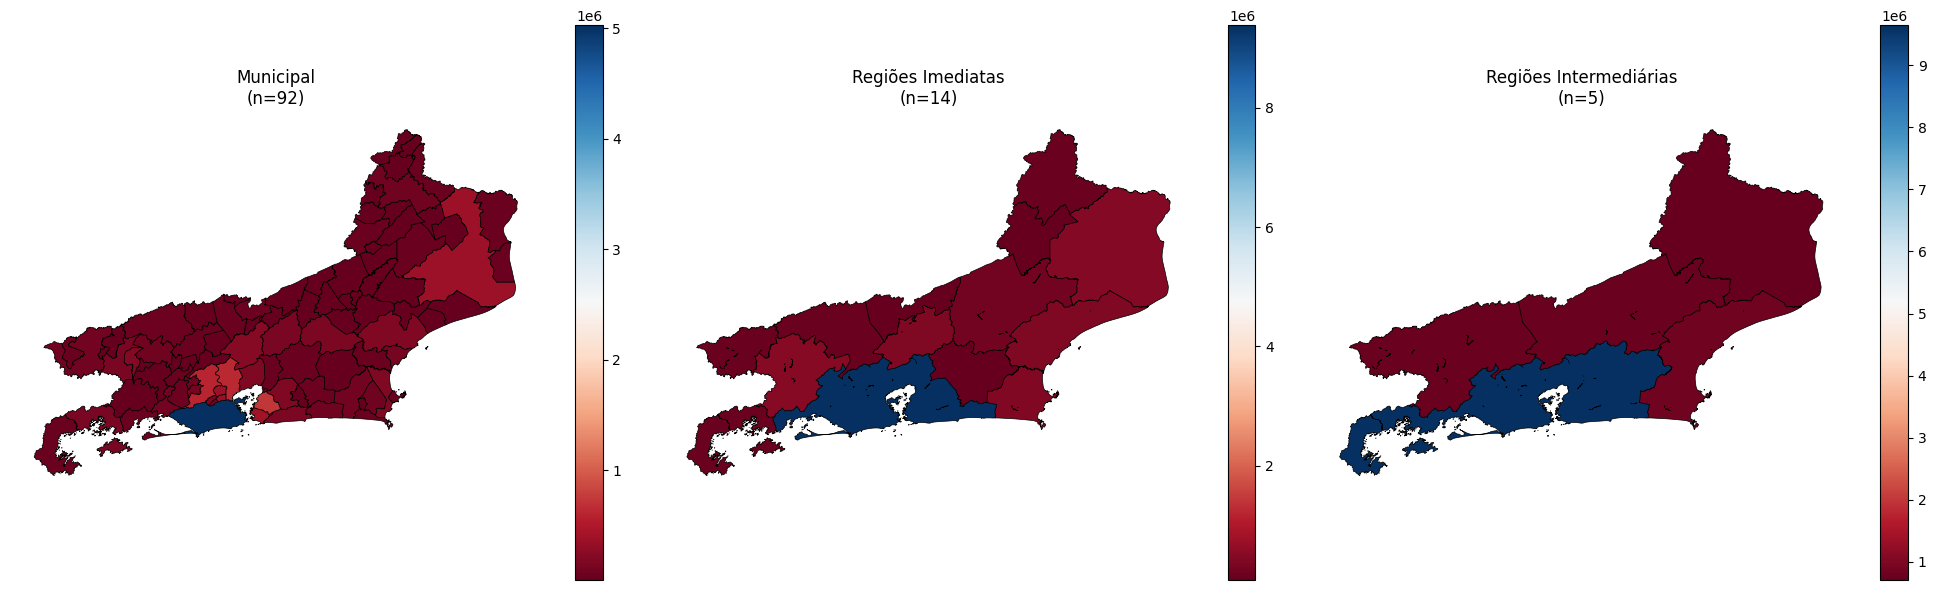

In [23]:
# 5. Agregações plotadas
fig, axes = plt.subplots(1, 3, figsize=(20, 6))


gdf_master.plot(column=target_variable, ax=axes[0], legend=True, cmap='RdBu', edgecolor='black', linewidth=0.5)
axes[0].set_title(f'Municipal\n(n={len(gdf_master)})')
axes[0].axis('off')

gdf_immediate.plot(column=target_variable, ax=axes[1], legend=True, cmap='RdBu', edgecolor='black', linewidth=0.5)
axes[1].set_title(f'Regiões Imediatas\n(n={len(gdf_immediate)})')
axes[1].axis('off')

gdf_intermediate.plot(column=target_variable, ax=axes[2], legend=True, cmap='RdBu', edgecolor='black', linewidth=0.5)
axes[2].set_title(f'Regiões Intermediárias\n(n={len(gdf_intermediate)})')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [24]:
# 1. Preparação dos dados

# 1.1 Dados de Votação
path_votos = "./DADOS/TSE/votos_filtrados.csv"
try:
    df_votos = pd.read_csv(path_votos, sep=';', encoding='latin1')
except FileNotFoundError:
    df_votos = pd.read_csv("./DADOS/TSE/votos_filtrados.csv.csv", sep=';', encoding='latin1')
    df_votos = df_votos[df_votos['CD_CARGO'] == 7]

# Calcula Total de Votos por Município (Proxy para população votante)
df_total_votos = df_votos.groupby('NM_MUNICIPIO')['QT_VOTOS_NOMINAIS'].sum().reset_index()
df_total_votos.columns = ['NM_MUNICIPIO', 'TOTAL_VOTOS_MUN']
df_total_votos['NM_MUNICIPIO'] = df_total_votos['NM_MUNICIPIO'].str.upper().str.strip()

# 1.2 Dados de Segurança (2021)
path_seg = "./DADOS/Seguranca/seguranca_municipios_2021.csv"
df_seg = pd.read_csv(path_seg, sep=';', encoding='latin1')
df_seg['TOTAL_CRIMES'] = df_seg['total_roubos'] + df_seg['total_furtos']
df_seg['fmun_cod'] = df_seg['fmun_cod'].astype(str)

path_alf = "./DADOS/Alfabetizacao/por_municipio_RJ.csv"
df_alf = pd.read_csv(path_alf, sep=';', encoding='latin1')
cols_alf = [c for c in df_alf.columns if c.startswith("V007")]
df_alf["TOTAL_ALFABETIZADOS"] = df_alf[cols_alf].sum(axis=1)
df_alf['CD_MUN'] = df_alf['CD_MUN'].astype(str)

In [25]:
# 2. Merge dos dados

if 'rj' not in locals():
    rj = gpd.read_file('./DADOS/MalhaGeometrica/rj_municipios/33MUE250GC_SIR.shp')

# Prepara GeoDataFrame base
gdf_analise = rj.copy()
gdf_analise['CD_GEOCODM'] = gdf_analise['CD_GEOCODM'].astype(str)

# Merge 1: Geometria + Alfabetização (Via Código IBGE)
gdf_analise = gdf_analise.merge(df_alf[['CD_MUN', 'TOTAL_ALFABETIZADOS']], 
                               left_on='CD_GEOCODM', right_on='CD_MUN', how='inner')

# Merge 2: + Segurança (Via Código IBGE)
gdf_analise = gdf_analise.merge(df_seg[['fmun_cod', 'TOTAL_CRIMES']], 
                               left_on='CD_GEOCODM', right_on='fmun_cod', how='inner')

# Merge 3: + Total de Votos (Via Nome do Município - TSE não usa código IBGE)
gdf_analise['NM_MUN_NORM'] = gdf_analise['NM_MUNICIP'].str.upper().str.strip()
gdf_analise = gdf_analise.merge(df_total_votos, left_on='NM_MUN_NORM', right_on='NM_MUNICIPIO', how='inner')

In [26]:
# 3. Criar indicadores normalizados
# Taxas normalizadas por total de votos (proxy de população)

gdf_analise['TAXA_ALFABETIZACAO'] = gdf_analise['TOTAL_ALFABETIZADOS'] / gdf_analise['TOTAL_VOTOS_MUN']
gdf_analise['TAXA_CRIMINALIDADE'] = gdf_analise['TOTAL_CRIMES'] / gdf_analise['TOTAL_VOTOS_MUN']

print(f"Base de análise pronta com {len(gdf_analise)} municípios.")

Base de análise pronta com 92 municípios.


Nenhum candidato especificado. Analisando os TOP 3: [44123, 22022, 50007]


C:\Users\Dell\AppData\Local\Temp\ipykernel_18480\4083949569.py:28: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf_final)



ANÁLISE: MARCIO CORREIA DE OLIVEIRA (44123)
--- vs Taxa Alfabetização ---
   Correlação Global (Pearson): -0.0013 (p=0.9903)
   Correlação Espacial (Moran Bivariado): 0.0368 (p=0.2620)
--- vs Taxa Criminalidade (Furtos+Roubos) ---
   Correlação Global (Pearson): 0.0967 (p=0.3593)
   Correlação Espacial (Moran Bivariado): 0.1931 (p=0.0020)


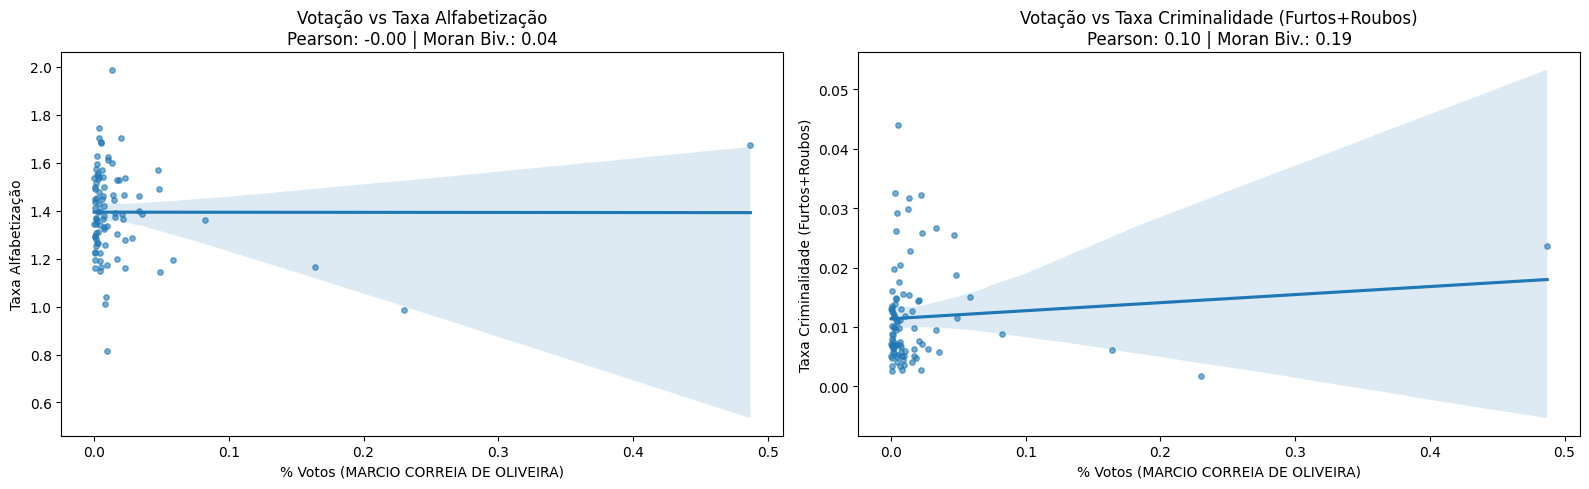

C:\Users\Dell\AppData\Local\Temp\ipykernel_18480\4083949569.py:28: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf_final)



ANÁLISE: DOUGLAS RUAS DOS SANTOS (22022)
--- vs Taxa Alfabetização ---
   Correlação Global (Pearson): 0.1919 (p=0.0669)
   Correlação Espacial (Moran Bivariado): 0.0640 (p=0.1770)
--- vs Taxa Criminalidade (Furtos+Roubos) ---
   Correlação Global (Pearson): 0.3048 (p=0.0031)
   Correlação Espacial (Moran Bivariado): 0.1534 (p=0.0360)


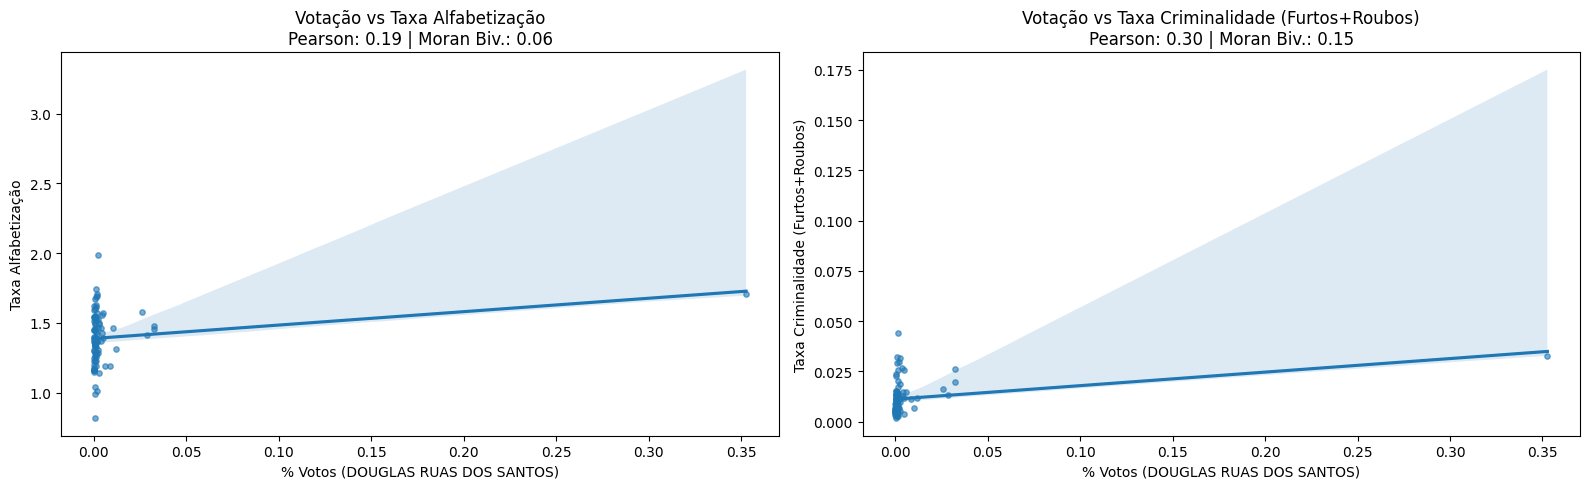

C:\Users\Dell\AppData\Local\Temp\ipykernel_18480\4083949569.py:28: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf_final)



ANÁLISE: RENATA DA SILVA SOUZA (50007)
--- vs Taxa Alfabetização ---
   Correlação Global (Pearson): 0.4974 (p=0.0000)
   Correlação Espacial (Moran Bivariado): 0.1627 (p=0.0020)
--- vs Taxa Criminalidade (Furtos+Roubos) ---
   Correlação Global (Pearson): 0.5746 (p=0.0000)
   Correlação Espacial (Moran Bivariado): 0.3106 (p=0.0010)


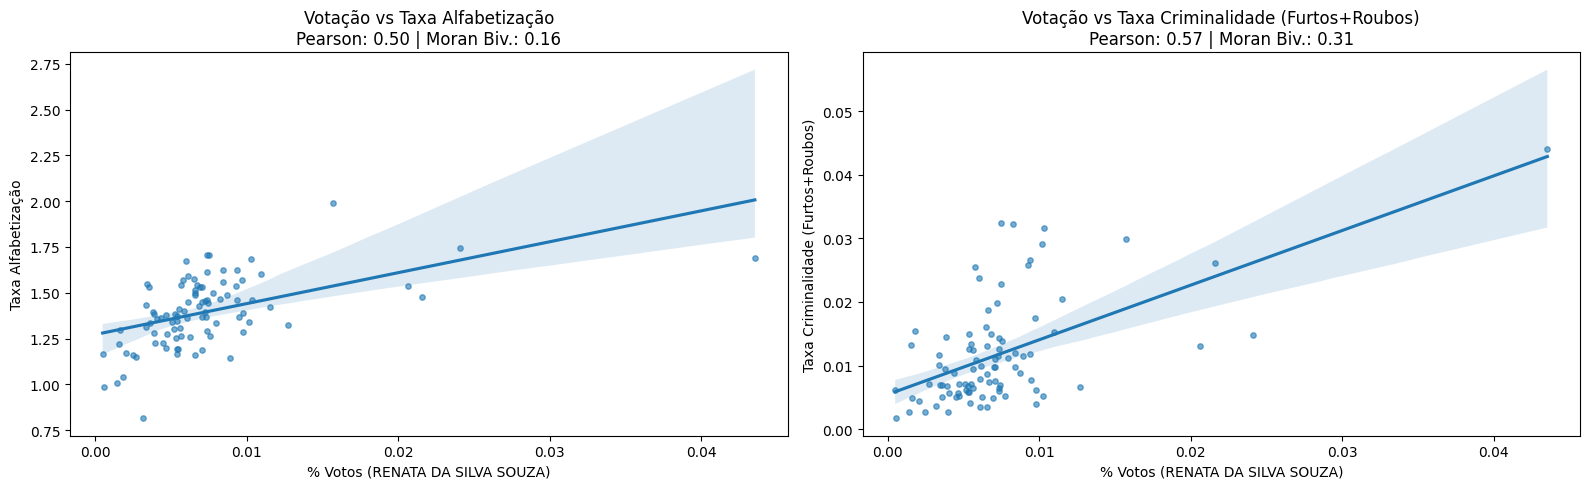

In [27]:
# 4. Análise de correlações para candidatos específicos

# Exemplo: CANDIDATOS_ALVO = [12345, 22222]
CANDIDATOS_ALVO = [] 

# Se a lista estiver vazia, pega os 3 mais votados automaticamente
if not CANDIDATOS_ALVO:
    top_cands = df_votos.groupby('NR_CANDIDATO')['QT_VOTOS_NOMINAIS_VALIDOS'].sum().sort_values(ascending=False).head(3).index.tolist()
    CANDIDATOS_ALVO = top_cands
    print(f"Nenhum candidato especificado. Analisando os TOP 3: {CANDIDATOS_ALVO}")

def analisar_candidato(numero_cand):
    # Filtra votos do candidato
    df_cand = df_votos[df_votos['NR_CANDIDATO'] == numero_cand]
    nome_cand = df_cand['NM_CANDIDATO'].iloc[0]
    
    # Agrupa por município
    votos_mun = df_cand.groupby('NM_MUNICIPIO')['QT_VOTOS_NOMINAIS_VALIDOS'].sum().reset_index()
    votos_mun['NM_MUNICIPIO'] = votos_mun['NM_MUNICIPIO'].str.upper().str.strip()
    
    # Junta com a base espacial
    gdf_final = gdf_analise.merge(votos_mun, on='NM_MUNICIPIO', how='left').fillna(0)
    
    # Calcula % de votos do candidato no município
    gdf_final['PERC_VOTOS'] = gdf_final['QT_VOTOS_NOMINAIS_VALIDOS'] / gdf_final['TOTAL_VOTOS_MUN']
    
    # Matriz de pesos espaciais (Vizinhos)
    w = Queen.from_dataframe(gdf_final)
    w.transform = 'r'
    
    vars_socio = {
        'Taxa Alfabetização': 'TAXA_ALFABETIZACAO',
        'Taxa Criminalidade (Furtos+Roubos)': 'TAXA_CRIMINALIDADE'
    }
    
    print(f"\n{'='*60}")
    print(f"ANÁLISE: {nome_cand} ({numero_cand})")
    print(f"{'='*60}")
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    for i, (label, col) in enumerate(vars_socio.items()):
        # 1. Correlação Simples (Pearson)
        corr, p_valor = pearsonr(gdf_final['PERC_VOTOS'], gdf_final[col])
        
        # 2. Correlação Espacial Bivariada (Moran)
        # Mede: Votos no município X vs Característica nos VIZINHOS de X
        moran_bv = Moran_BV(gdf_final['PERC_VOTOS'], gdf_final[col], w)
        
        print(f"--- vs {label} ---")
        print(f"   Correlação Global (Pearson): {corr:.4f} (p={p_valor:.4f})")
        print(f"   Correlação Espacial (Moran Bivariado): {moran_bv.I:.4f} (p={moran_bv.p_sim:.4f})")
        
        # Plot
        sns.regplot(x='PERC_VOTOS', y=col, data=gdf_final, ax=axes[i], scatter_kws={'s': 15, 'alpha': 0.6})
        axes[i].set_title(f"Votação vs {label}\nPearson: {corr:.2f} | Moran Biv.: {moran_bv.I:.2f}")
        axes[i].set_xlabel(f"% Votos ({nome_cand})")
        axes[i].set_ylabel(label)
        
    plt.tight_layout()
    plt.show()

# Executa para cada candidato
for cand in CANDIDATOS_ALVO:
    analisar_candidato(cand)

In [28]:
if 'CD_CARGO' in df_votos.columns:
    df_dep = df_votos[df_votos['CD_CARGO'] == 7].copy()
else:
    # Se a coluna não existe, assumimos que o df_votos já está filtrado
    df_dep = df_votos.copy()

# Nomes corretos das colunas para o arquivo de Votação por Município/Zona
colunas_agrupamento = ["CD_MUNICIPIO", "NM_MUNICIPIO", "NR_CANDIDATO", "NM_CANDIDATO"]

# Verifica qual coluna de votos está disponível (VALIDOS ou NOMINAIS)
coluna_votos = "QT_VOTOS_NOMINAIS_VALIDOS"
if coluna_votos not in df_dep.columns:
    coluna_votos = "QT_VOTOS_NOMINAIS"

# Agrupar por município e candidato
df_votos_mun = df_dep.groupby(colunas_agrupamento, as_index=False)[coluna_votos].sum()

# Votação total por candidato no estado (Ranking)
ranking = df_votos_mun.groupby(["NR_CANDIDATO", "NM_CANDIDATO"])[coluna_votos].sum().sort_values(ascending=False)

# Exibe o TOP 10
print(ranking.head(10))

NR_CANDIDATO  NM_CANDIDATO                       
44123         MARCIO CORREIA DE OLIVEIRA             181274
22022         DOUGLAS RUAS DOS SANTOS                175977
50007         RENATA DA SILVA SOUZA                  174132
15016         ROSENVERG REIS DE OLIVEIRA             131308
22122         SÉRGIO LUIZ COSTA AZEVEDO FILHO        123739
22222         GUILHERME JANDRE DELAROLI              114155
22200         THIAGO GAGLIASSO ONOFRE FERREIRA       102038
22789         RODRIGO DA SILVA BACELLAR               97822
13021         ELIKA TAKIMOTO                          95263
22822         GISELLE LOUISE MONTEIRO DE OLIVEIRA     95028
Name: QT_VOTOS_NOMINAIS_VALIDOS, dtype: int64


In [29]:
# 1. Total de votos por município (Correção: QT_VOTOS -> QT_VOTOS_NOMINAIS_VALIDOS)
total_mun = df_dep.groupby("CD_MUNICIPIO")["QT_VOTOS_NOMINAIS"].sum().reset_index()
total_mun.rename(columns={"QT_VOTOS_NOMINAIS": "TOTAL_VOTOS"}, inplace=True)

# 2. Junta com votos por candidato
df_votos_mun = df_votos_mun.merge(total_mun, on="CD_MUNICIPIO")

# 3. Cria proporção (Correção: usar as colunas renomeadas corretamente)
df_votos_mun["PERC_VOTOS"] = df_votos_mun["QT_VOTOS_NOMINAIS_VALIDOS"] / df_votos_mun["TOTAL_VOTOS"]

# Carrega Segurança
df_seg = pd.read_csv("./DADOS/Seguranca/seguranca_municipios_2021.csv", sep=';', encoding='latin1')
df_seg["total_crimes"] = df_seg["total_furtos"] + df_seg["total_roubos"]

# Normaliza nomes para o cruzamento (já que os códigos TSE e IBGE são diferentes)
df_seg['NM_MUN_NORM'] = df_seg['fmun'].str.upper().str.strip()
df_votos_mun['NM_MUN_NORM'] = df_votos_mun['NM_MUNICIPIO'].str.upper().str.strip()

# Exemplo com um candidato escolhido
codigo_candidato = 22222  # <-- Insira um número real aqui (ex: PL)

# Correção: NR_VOTAVEL -> NR_CANDIDATO
df_cand = df_votos_mun[df_votos_mun["NR_CANDIDATO"] == codigo_candidato]

if len(df_cand) == 0:
    print(f"Candidato {codigo_candidato} não encontrado ou sem votos.")
else:
    # 4. Juntar com criminalidade (Correção: Merge por NOME, não por código)
    df_corr = df_cand.merge(df_seg, on="NM_MUN_NORM")

    if len(df_corr) > 0:
        # Correção: Calcular correlação apenas se houver dados
        corr = df_corr["PERC_VOTOS"].corr(df_corr["total_crimes"])
        print(f"Análise para: {df_cand['NM_CANDIDATO'].iloc[0]}")
        print(f"Correlação entre % de votos e total de crimes: {corr:.3f}")
    else:
        print("Erro no cruzamento dos municípios. Verifique os nomes.")

Análise para: GUILHERME JANDRE DELAROLI
Correlação entre % de votos e total de crimes: -0.007


📍 Analisando os Top 4 Partidos: ['PL', 'UNIÃO', 'PSD', 'PT']
> PL: Moran=0.429 (Agrupado (Curral/Base Local))
> UNIÃO: Moran=0.164 (Disperso (Voto de Opinião/Geral))
> PSD: Moran=0.110 (Disperso (Voto de Opinião/Geral))
> PT: Moran=0.201 (Disperso (Voto de Opinião/Geral))


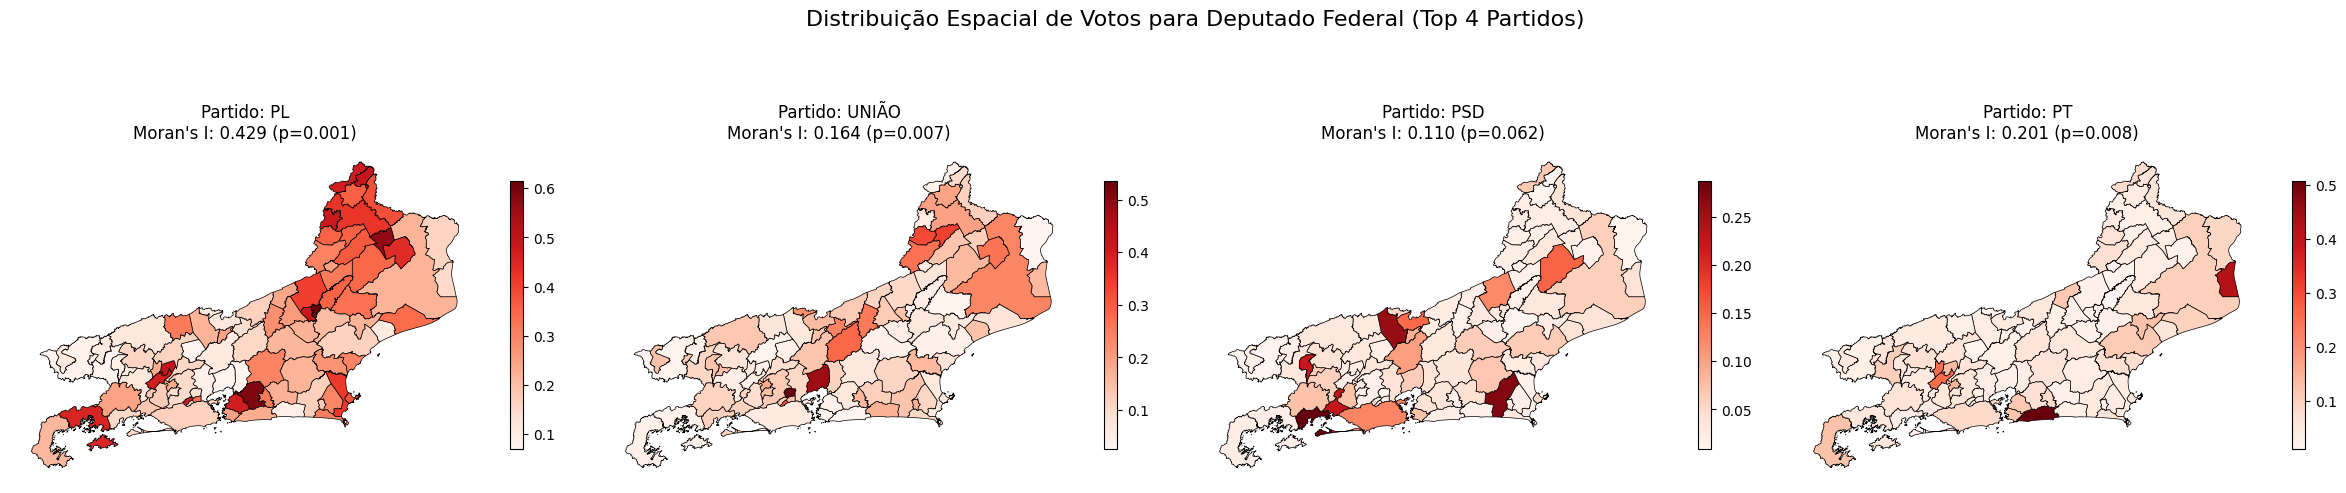

In [30]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from esda.moran import Moran
from libpysal.weights import Queen
import numpy as np
import warnings

# Ignorar avisos de compatibilidade futura para limpar a saída
warnings.simplefilter(action='ignore', category=FutureWarning)

# --- 1. CARREGAR E PREPARAR DADOS ---

df_fed = pd.read_csv("./DADOS/TSE/votos_filtrados.csv", sep=';', encoding='latin1')

# Garante a coluna de votos correta
col_votos = 'QT_VOTOS_NOMINAIS' if 'QT_VOTOS_NOMINAIS' in df_fed.columns else 'QT_VOTOS_NOMINAIS_VALIDOS'

# --- 2. CÁLCULO DE VOTOS POR PARTIDO ---

# Total de votos por Município
total_mun = df_fed.groupby('NM_MUNICIPIO')[col_votos].sum().reset_index()
total_mun.rename(columns={col_votos: 'TOTAL_VOTOS_MUN'}, inplace=True)

# Votos por Partido e Município
col_partido = 'SG_PARTIDO' if 'SG_PARTIDO' in df_fed.columns else 'NR_PARTIDO'
df_partido = df_fed.groupby(['NM_MUNICIPIO', col_partido])[col_votos].sum().reset_index()

# Junta os totais para calcular a porcentagem
df_partido = df_partido.merge(total_mun, on='NM_MUNICIPIO')
df_partido['PERC_VOTOS'] = df_partido[col_votos] / df_partido['TOTAL_VOTOS_MUN']

# --- 3. SELEÇÃO DOS PARTIDOS MAIS REPRESENTATIVOS ---
top_partidos = df_partido.groupby(col_partido)[col_votos].sum().sort_values(ascending=False).head(4).index.tolist()
print(f"📍 Analisando os Top 4 Partidos: {top_partidos}")

# --- 4. PREPARAÇÃO ESPACIAL ---
if 'rj' not in locals():
    rj = gpd.read_file('./DADOS/MalhaGeometrica/rj_municipios/33MUE250GC_SIR.shp')

# Normalização de nomes
rj['NM_MUN_NORM'] = rj['NM_MUNICIP'].str.upper().str.strip()
df_partido['NM_MUN_NORM'] = df_partido['NM_MUNICIPIO'].str.upper().str.strip()

# --- 5. ANÁLISE DE AUTOCORRELAÇÃO (LOOP) ---

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for i, partido in enumerate(top_partidos):
    # Filtra apenas o partido da vez
    df_p = df_partido[df_partido[col_partido] == partido]
    
    # Merge com o mapa
    gdf_p = rj.merge(df_p, on='NM_MUN_NORM', how='left')
    gdf_p['PERC_VOTOS'] = gdf_p['PERC_VOTOS'].fillna(0)
    
    # Matriz de Pesos (Queen) - CORREÇÃO AQUI (use_index=True)
    w = Queen.from_dataframe(gdf_p, use_index=True)
    w.transform = 'r'
    
    # Cálculo do Moran's I
    y = gdf_p['PERC_VOTOS'].values
    moran = Moran(y, w)
    
    # Plotagem
    gdf_p.plot(column='PERC_VOTOS', ax=axes[i], legend=True, cmap='Reds', legend_kwds={'shrink': 0.5}, edgecolor='black', linewidth=0.5)
    
    # Título
    axes[i].set_title(f"Partido: {partido}\nMoran's I: {moran.I:.3f} (p={moran.p_sim:.3f})")
    axes[i].axis('off')
    
    # Interpretação
    interp = "Agrupado (Curral/Base Local)" if moran.I > 0.3 else "Disperso (Voto de Opinião/Geral)"
    print(f"> {partido}: Moran={moran.I:.3f} ({interp})")

plt.suptitle("Distribuição Espacial de Votos para Deputado Federal (Top 4 Partidos)", fontsize=16)
plt.tight_layout()
plt.show()

### EXPORTAÇÃO DE DADOS TRATADOS PARA UTILIZAÇÃO NO QGIS

In [31]:
import pandas as pd
import geopandas as gpd
import os
import numpy as np
import warnings

# Ignorar avisos de compatibilidade
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

print("INICIANDO PREPARAÇÃO E EXPORTAÇÃO DOS DADOS PARA QGIS...")

# Configurar diretório de saída
output_dir = "./DADOS/Output_QGIS"
os.makedirs(output_dir, exist_ok=True)

# --- 1. CARREGAMENTO DA GEOMETRIA (BASE PARA TUDO) ---
print("Carregando malha geométrica...")
path_shp = './DADOS/MalhaGeometrica/rj_municipios/33MUE250GC_SIR.shp'
if not os.path.exists(path_shp):
    raise FileNotFoundError(f"Arquivo de shapefile não encontrado: {path_shp}")

rj = gpd.read_file(path_shp)
rj['CD_GEOCODM'] = rj['CD_GEOCODM'].astype(str)
# Normaliza nome para merges futuros
rj['NM_MUN_NORM'] = rj['NM_MUNICIP'].str.upper().str.strip()

# --- 2. RECRIAÇÃO DOS DADOS DE ALFABETIZAÇÃO (PARA O 4B) ---
print("Preparando dados de Alfabetização...")
df_alf = pd.read_csv("./DADOS/Alfabetizacao/por_municipio_RJ.csv", sep=';', encoding='latin1')
cols_alf = [c for c in df_alf.columns if c.startswith("V007")]
df_alf["TOTAL_ALFABETIZADOS"] = df_alf[cols_alf].sum(axis=1)
df_alf['CD_MUN'] = df_alf['CD_MUN'].astype(str)

# Pegar Hierarquia IBGE (Necessário para as regiões)
try:
    url_ibge = "https://servicodados.ibge.gov.br/api/v1/localidades/estados/33/municipios?view=nivelado"
    df_hierarchy = pd.read_json(url_ibge)
    df_hierarchy = df_hierarchy[['municipio-id', 'regiao-imediata-nome', 'regiao-intermediaria-nome']]
    df_hierarchy['municipio-id'] = df_hierarchy['municipio-id'].astype(str)
    
    # Merge Master
    gdf_master = rj.merge(df_alf, left_on='CD_GEOCODM', right_on='CD_MUN', how='inner')
    gdf_master = gdf_master.merge(df_hierarchy, left_on='CD_GEOCODM', right_on='municipio-id', how='inner')
    
    # Agregações
    gdf_immediate = gdf_master.dissolve(by='regiao-imediata-nome', aggfunc={'TOTAL_ALFABETIZADOS': 'sum'})
    gdf_intermediate = gdf_master.dissolve(by='regiao-intermediaria-nome', aggfunc={'TOTAL_ALFABETIZADOS': 'sum'})
    
    # EXPORTAÇÃO 4B
    print("Salvando mapas de Alfabetização...")
    path_alf_municipal =   f"{output_dir}/Mapa_Alfabetizacao_Municipal.shp"
    path_alf_immediate = f"{output_dir}/Mapa_Alfabetizacao_RegiaoImediata.shp"
    path_alf_intermediate = f"{output_dir}/Mapa_Alfabetizacao_RegiaoIntermediaria.shp"

    if not os.path.exists(path_alf_municipal):
        gdf_master[['CD_GEOCODM', 'NM_MUNICIP', 'TOTAL_ALFABETIZADOS', 'geometry']].to_file(path_alf_municipal, encoding='utf-8')
    else:
        print(f"📌 Arquivo já existe, não será recriado: {path_alf_municipal}")

    if not os.path.exists(path_alf_immediate):
        gdf_immediate.to_file(path_alf_immediate, encoding='utf-8')
    else:
        print(f"📌 Arquivo já existe, não será recriado: {path_alf_immediate}")

    if not os.path.exists(path_alf_intermediate):
        gdf_intermediate.to_file(path_alf_intermediate, encoding='utf-8')
    else:
        print(f"📌 Arquivo já existe, não será recriado: {path_alf_intermediate}")
    
except Exception as e:
    print(f"Erro na parte de Alfabetização: {e}")

# --- 3. RECRIAÇÃO DOS DADOS SOCIOECONÔMICOS E VOTOS (PARA O 4C) ---
print("Preparando dados Socioeconômicos e Candidatos...")

# Carregar Segurança
df_seg = pd.read_csv("./DADOS/Seguranca/seguranca_municipios_2021.csv", sep=';', encoding='latin1')
df_seg['TOTAL_CRIMES'] = df_seg['total_roubos'] + df_seg['total_furtos']
df_seg['fmun_cod'] = df_seg['fmun_cod'].astype(str)

# Carregar Votos (Estadual)
df_votos = pd.read_csv("./DADOS/TSE/votos_filtrados.csv", sep=';', encoding='latin1')

# Totais por município
df_total_votos = df_votos.groupby('NM_MUNICIPIO')['QT_VOTOS_NOMINAIS'].sum().reset_index()
df_total_votos.columns = ['NM_MUNICIPIO', 'TOTAL_VOTOS_MUN']
df_total_votos['NM_MUNICIPIO'] = df_total_votos['NM_MUNICIPIO'].str.upper().str.strip()

# Merge Geral (gdf_analise)
gdf_analise = rj.copy()
gdf_analise = gdf_analise.merge(df_alf[['CD_MUN', 'TOTAL_ALFABETIZADOS']], left_on='CD_GEOCODM', right_on='CD_MUN', how='inner')
gdf_analise = gdf_analise.merge(df_seg[['fmun_cod', 'TOTAL_CRIMES']], left_on='CD_GEOCODM', right_on='fmun_cod', how='inner')
gdf_analise = gdf_analise.merge(df_total_votos, left_on='NM_MUN_NORM', right_on='NM_MUNICIPIO', how='inner')

# Indicadores
gdf_analise['TAXA_ALFA'] = gdf_analise['TOTAL_ALFABETIZADOS'] / gdf_analise['TOTAL_VOTOS_MUN']
# print(gdf_analise[['NM_MUNICIP', 'TAXA_ALFA', 'TOTAL_ALFABETIZADOS', 'TOTAL_VOTOS_MUN']].head())
gdf_analise['TAXA_CRIME'] = gdf_analise['TOTAL_CRIMES'] / gdf_analise['TOTAL_VOTOS_MUN']

# Adicionar Votos dos TOP 3 Candidatos
CANDIDATOS_ALVO = df_votos.groupby('NR_CANDIDATO')['QT_VOTOS_NOMINAIS'].sum().sort_values(ascending=False).head(3).index.tolist()
gdf_export_socio = gdf_analise.copy()

for cand in CANDIDATOS_ALVO:
    df_cand = df_votos[df_votos['NR_CANDIDATO'] == cand]
    votos_mun = df_cand.groupby('NM_MUNICIPIO')['QT_VOTOS_NOMINAIS'].sum().reset_index()
    votos_mun['NM_MUNICIPIO'] = votos_mun['NM_MUNICIPIO'].str.upper().str.strip()
    
    temp = gdf_export_socio.merge(votos_mun, left_on='NM_MUN_NORM', right_on='NM_MUNICIPIO', how='left').fillna(0)
    # Coluna renomeada para ser amigável ao Shapefile (max 10 chars)
    gdf_export_socio[f'VOT_{cand}'] = temp['QT_VOTOS_NOMINAIS'] / temp['TOTAL_VOTOS_MUN']

# EXPORTAÇÃO 4C
print("Salvando mapa Socioeconômico...")
cols_to_keep = ['NM_MUNICIP', 'CD_GEOCODM', 'geometry', 'TAXA_ALFA', 'TAXA_CRIME'] + [f'VOT_{c}' for c in CANDIDATOS_ALVO]

path_socio_votos = f"{output_dir}/Mapa_Socioeconomico_Votos.shp"
if not os.path.exists(path_socio_votos):
    gdf_export_socio[cols_to_keep].to_file(path_socio_votos, encoding='utf-8')
else:
    print(f"📌 Arquivo já existe, não será recriado: {path_socio_votos}")


# --- 4. RECRIAÇÃO DOS DADOS DE PARTIDOS (PARA O 4E) ---
print("Preparando dados de Partidos (Dep. Federal)...")

# Carregar Votos (Federal)
df_fed = pd.read_csv("./DADOS/TSE/votos_filtrados.csv", sep=';', encoding='latin1') # Fallback

col_votos = 'QT_VOTOS_NOMINAIS' if 'QT_VOTOS_NOMINAIS' in df_fed.columns else 'QT_VOTOS_NOMINAIS_VALIDOS'
col_partido = 'SG_PARTIDO' if 'SG_PARTIDO' in df_fed.columns else 'NR_PARTIDO'

# Totais e Percentuais
total_mun_fed = df_fed.groupby('NM_MUNICIPIO')[col_votos].sum().reset_index()
total_mun_fed.rename(columns={col_votos: 'TOTAL_VOTOS_MUN'}, inplace=True)

df_partido = df_fed.groupby(['NM_MUNICIPIO', col_partido])[col_votos].sum().reset_index()
df_partido = df_partido.merge(total_mun_fed, on='NM_MUNICIPIO')
df_partido['PERC_VOTOS'] = df_partido[col_votos] / df_partido['TOTAL_VOTOS_MUN']
df_partido['NM_MUN_NORM'] = df_partido['NM_MUNICIPIO'].str.upper().str.strip()

# Top 4 Partidos
top_partidos = df_partido.groupby(col_partido)[col_votos].sum().sort_values(ascending=False).head(4).index.tolist()

# Montar GeoDataFrame Final
gdf_partidos_export = rj[['NM_MUN_NORM', 'geometry']].copy()

for partido in top_partidos:
    df_p = df_partido[df_partido[col_partido] == partido]
    gdf_partidos_export = gdf_partidos_export.merge(df_p[['NM_MUN_NORM', 'PERC_VOTOS']], on='NM_MUN_NORM', how='left')
    
    # Renomear para evitar conflito e respeitar limite do Shapefile
    safe_partido = str(partido).replace(" ", "")[:7]
    gdf_partidos_export.rename(columns={'PERC_VOTOS': f'P_{safe_partido}'}, inplace=True)

gdf_partidos_export = gdf_partidos_export.fillna(0)

# EXPORTAÇÃO 4E
print("Salvando mapa de Partidos...")
path_votos_partidos = f"{output_dir}/Mapa_Votos_Partidos.shp"
if not os.path.exists(path_votos_partidos):
    gdf_partidos_export.to_file(path_votos_partidos, encoding='utf-8')
else: 
    print(f"📌 Arquivo já existe, não será recriado: {path_votos_partidos}")

print("\n PROCESSO CONCLUÍDO! Todos os arquivos estão na pasta 'DADOS/Output_QGIS'.")

INICIANDO PREPARAÇÃO E EXPORTAÇÃO DOS DADOS PARA QGIS...
Carregando malha geométrica...
Preparando dados de Alfabetização...
Salvando mapas de Alfabetização...
📌 Arquivo já existe, não será recriado: ./DADOS/Output_QGIS/Mapa_Alfabetizacao_Municipal.shp
📌 Arquivo já existe, não será recriado: ./DADOS/Output_QGIS/Mapa_Alfabetizacao_RegiaoImediata.shp
📌 Arquivo já existe, não será recriado: ./DADOS/Output_QGIS/Mapa_Alfabetizacao_RegiaoIntermediaria.shp
Preparando dados Socioeconômicos e Candidatos...
Salvando mapa Socioeconômico...
📌 Arquivo já existe, não será recriado: ./DADOS/Output_QGIS/Mapa_Socioeconomico_Votos.shp
Preparando dados de Partidos (Dep. Federal)...
Salvando mapa de Partidos...
📌 Arquivo já existe, não será recriado: ./DADOS/Output_QGIS/Mapa_Votos_Partidos.shp

 PROCESSO CONCLUÍDO! Todos os arquivos estão na pasta 'DADOS/Output_QGIS'.
